In [1]:
import numpy as np
import pandas as pd

In [2]:
mse = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/mse_output_loss_results.tsv", sep="\t")

In [3]:
mse["output_loss"] = ["mse" for i in range(len(mse))]

In [4]:
l1_loss_control = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/tau_1.0_results.tsv", sep="\t")

In [5]:
l1_loss_control["output_loss"] = ["l1" for i in range(len(l1_loss_control))]

In [6]:
df = pd.concat([mse, l1_loss_control], ignore_index=True)

In [9]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'best_output_loss',
       'num_edits', 'best_PearsonR', 'SCD', 'URQ_result', 'URQ_target',
       'URQ_init', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions',
       'output_loss', 'URQ_diff'],
      dtype='object')

In [8]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/SLURM_1061221/ipykernel_240350/299819289.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='output_loss', y=metric, ax=ax, palette="Set2")
/tmp/SLURM_1061221/ipykernel_240350/299819289.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='output_loss', y=metric, ax=ax, palette="Set2")
/tmp/SLURM_1061221/ipykernel_240350/299819289.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='output_loss', y=metric, ax=ax, palette="Set2")
/tmp/SLURM_1061221/ipykernel_240350/299819289.py:20: FutureWarning: 

Pas

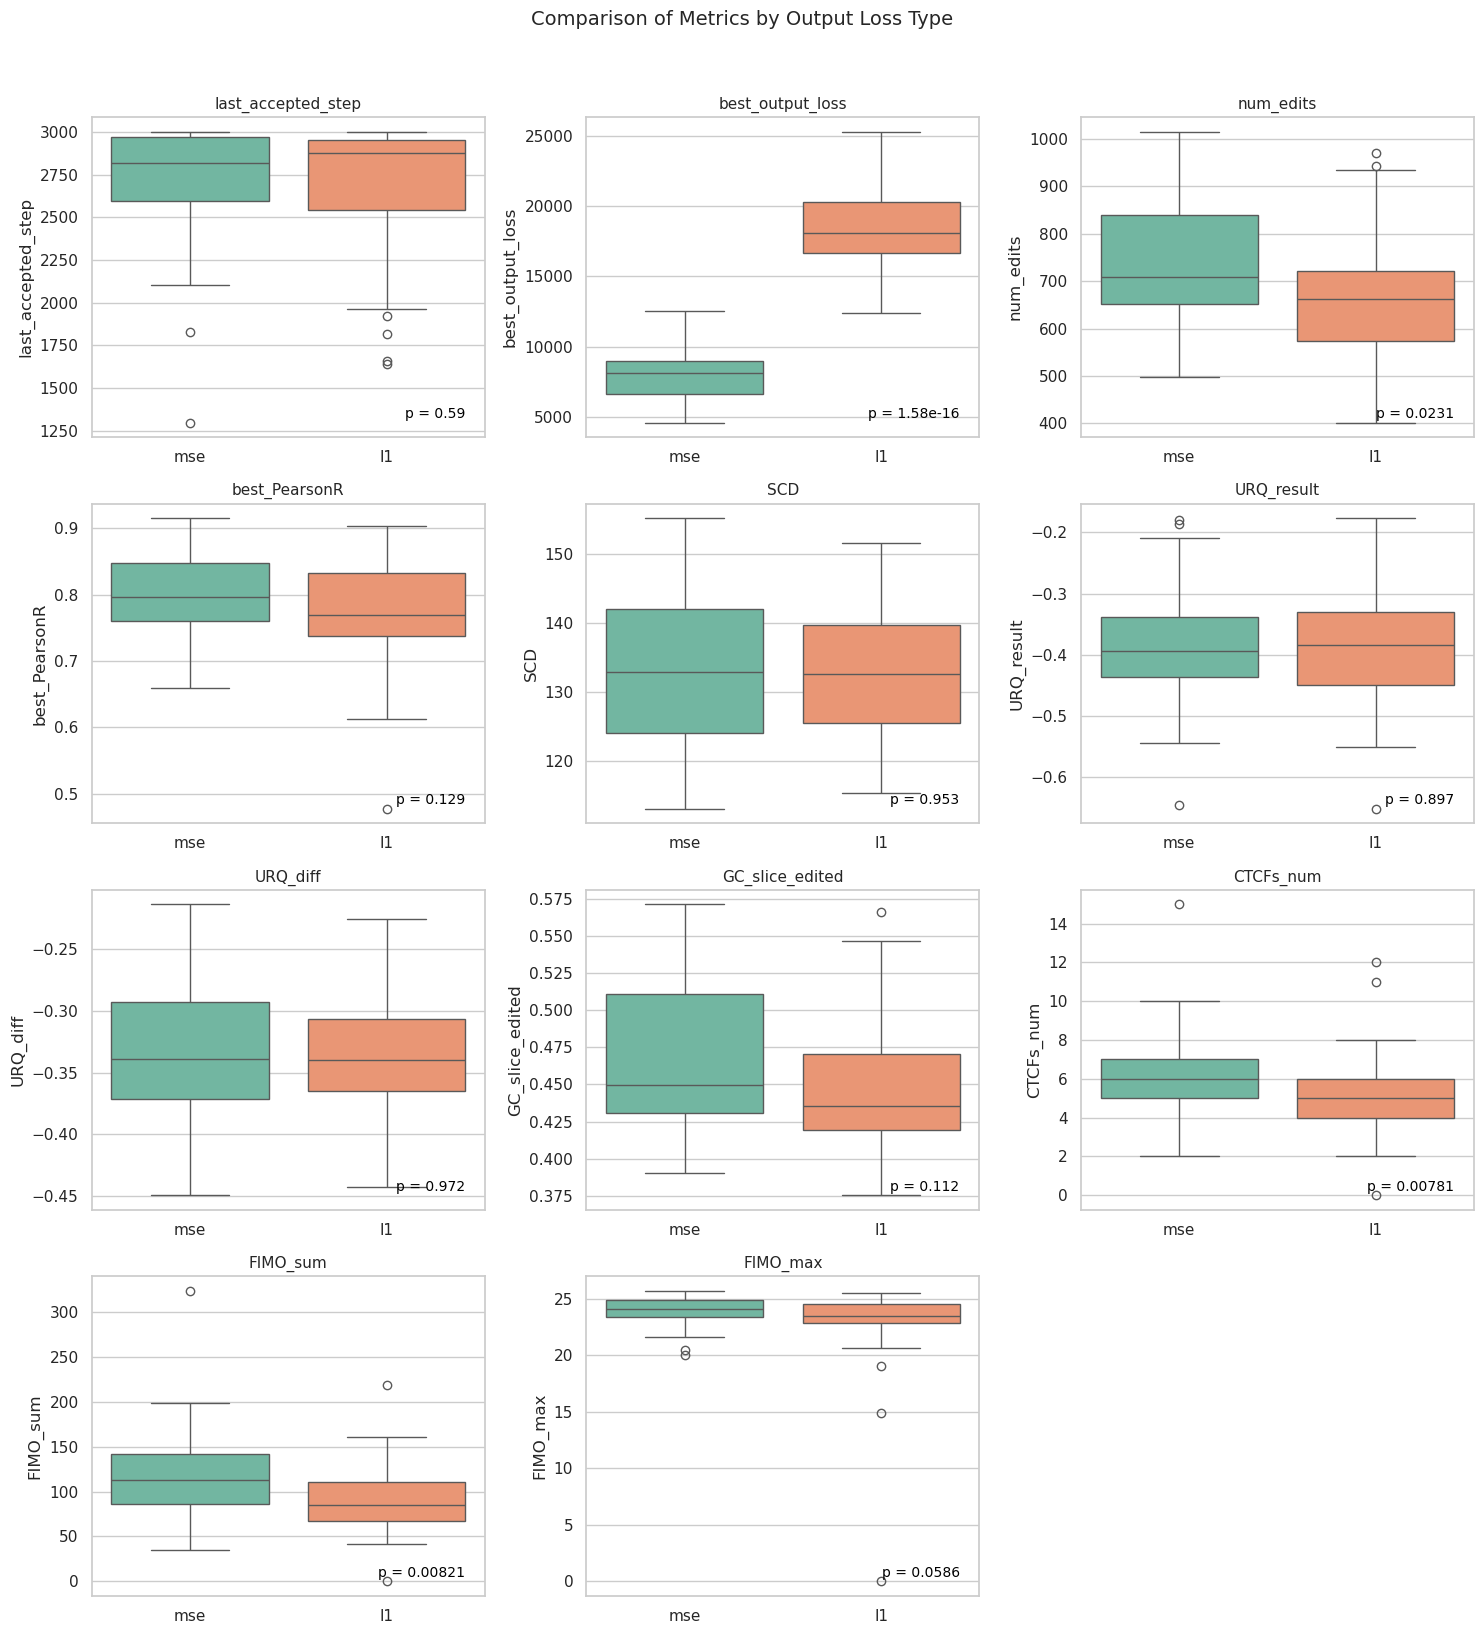

In [12]:
from scipy.stats import mannwhitneyu

# Full list of metrics to compare
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Set up grid layout (adjust based on how many metrics you have)
n_cols = 3
n_rows = -(-len(metrics) // n_cols)  # Ceiling division

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='output_loss', y=metric, ax=ax, palette="Set2")
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(metric)

    # Optional: add p-value from Mann-Whitney U test
    mse_vals = df[df['output_loss'] == 'mse'][metric].dropna()
    l1_vals = df[df['output_loss'] == 'l1'][metric].dropna()
    try:
        stat, pval = mannwhitneyu(mse_vals, l1_vals, alternative='two-sided')
        ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='black')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused subplots if metric count doesn't fill grid
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Comparison of Metrics by Output Loss Type", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
